# FRLC Demo notebook

_Factor relaxation with latent coupling_ (abbreviated FRLC with the mnemonic "frolic") solves for a rank $r$ optimal transport coupling $\mathbf{P} \in \Pi_{r}(\mathbf{a}, \mathbf{b})$ which aligns a distribution $\mathbf{a}$ to a distribution $\mathbf{b}$ with least Wasserstein cost

$$\mathbf{P}^{*} = \arg\min_{\mathbf{P} \in \Pi_{r}(\mathbf{a}, \mathbf{b})} \langle \mathbf{C}, \mathbf{P} \rangle_{F} $$

by returning a factorization of $\mathbf{P}$ in terms of two sub-couplings $\mathbf{Q}, \mathbf{R}$ and a latent coupling $\mathbf{T}$ $$\mathbf{P} = \mathbf{Q} \mathrm{diag}(1 / \mathbf{g}_{Q}) \mathbf{T} \mathrm{diag}(1 / \mathbf{g}_{R}) \mathbf{R}^{T} $$
where one can imagine this coarsening the full transport $(\mathbf{P}, \mathbf{a}, \mathbf{b}) \mapsto (\mathbf{T}, \mathbf{g}_{Q}, \mathbf{g}_{R})$ from being over the observed datapoints to $r$ latent clusters. The latent coupling, importantly, can be non-diagonal and represent hidden non-square transitions in the transport. In this simple demo notebook, we demonstrate how to use FRLC and visualize interpretable outputs from it.

In [1]:
# Packages for generating example datasets
import numpy as np
import torch
import torchdyn
from torchdyn.datasets import generate_moons
from scipy.spatial import distance
import matplotlib.pyplot as plt
# Import FRLC packages
import sys
sys.path.insert(0, '../src')
import FRLC.FRLC as frlc
import convex_lrot as clrot

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

# 2-Moons and 8-Gaussians

We evaluate use the simple synthetic dataset of:
https://github.com/atong01/conditional-flow-matching/blob/main/examples/2D_tutorials/tutorial_training_8_gaussians_to_moons.ipynb. The alignment task for this dataset concerns aligning two-moons with 8-spatially localized 2D-Gaussian densities.

In [3]:
import math 

def eight_normal_sample(n, dim, scale=1, var=1):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), math.sqrt(var) * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data


def sample_moons(n):
    x0, _ = generate_moons(n, noise=0.5)
    return x0 * 3 - 1

def sample_8gaussians(n):
    return eight_normal_sample(n, 2, scale=5, var=0.2).float()

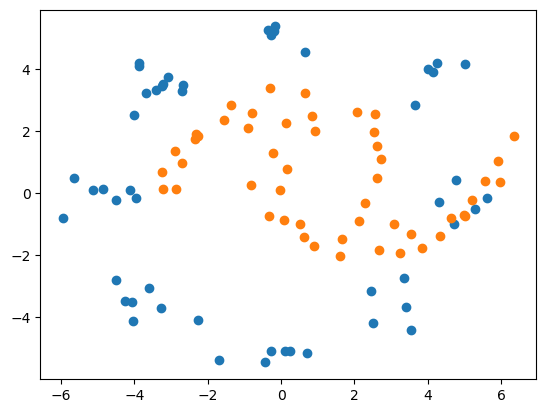

In [ ]:
from ott.geometry import pointcloud, geometry

batch_size1 = 500
batch_size2 = 500

g1 = np.ones((batch_size1)) / batch_size1
g2 = np.ones((batch_size2)) / batch_size2

x0 = sample_8gaussians(batch_size1)
x1 = sample_moons(batch_size2)

plt.scatter(x0[:,0], x0[:,1])
plt.scatter(x1[:,0], x1[:,1])
plt.show()

C = torch.from_numpy(distance.cdist(x0, x1)).to(device)
# We recommended normalizing input distance matrices by the max-value for numerical stability and may make this a default.
C = C / C.max()

To run the method, simply call <tt>` FRLC.FRLC_opt `</tt> on the distance matrices used (e.g. $\mathbf{C}$ for the Wasserstein problem, $\mathbf{A}, \mathbf{B}$ for GW or in addition to $\mathbf{C}$ for FGW). You can toggle the type of optimization with the flag <tt>`Wasserstein=True`</tt> or <tt>`Wasserstein=False`</tt> and <tt>`FGW=True`</tt>. Additional flags <tt>`semiRelaxedLeft=True`</tt>, <tt>`semiRelaxedRight=True`</tt>, or <tt>`semiRelaxedRight=True`</tt> can be set to pick between standard relaxed OT problems. If all flags are False (default), then the OT run is balanced.

By default, we assume that the return is in the form $(\mathbf{Q}, \mathbf{R}, \mathbf{T})$ where one has access to the latent coupling $\mathbf{T}$ and the sub-couplings $\mathbf{Q}$ and $\mathbf{R}$ which map from the observed points to the latent points. Setting <tt>` returnFull = True `</tt> will return the full low-rank alignment matrix $\mathbf{P}$ instead.

In [5]:
P, errs = frlc.FRLC_opt(C, device=device, r=10, max_iter=20, returnFull=True, gamma=70, max_inneriters_balanced=500, max_inneriters_relaxed=500)

print(f'OT cost of FRLC: {(P * C).sum()}')

print(P.sum(axis=0))
print(P.sum(axis=1))
print(P.sum())
print(np.linalg.svd(P)[1])

Iteration: 0
OT cost of FRLC: 0.2611109304950774
tensor([0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200], dtype=torch.float64)
tensor([0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200], dtype=torch.float64)
tensor(1., 

In [14]:
import convex_lrot as clrot
import importlib
import jax.numpy as jnp
importlib.reload(clrot)

# L, R, obj = clrot.solve_low_rank_ot_alternating_lp(C.cpu().numpy(), g1, g2, 10, 25)

P, obj = clrot.solve_nuclear_ot(
    jnp.asarray(C.cpu().numpy()),
    jnp.asarray(g1),
    jnp.asarray(g2),
    10,
    1.0 / (min(g1.shape[0], g2.shape[0])), # gamma \defeq max {||P||_\sigma : P \in \Pi_{a,b}}
    max_iter=100,
    tolerance=1e-6,
    rho=200,
    verbose=True
)

#P, obj = clrot.solve_linear_ot_cvxpy(C.cpu().numpy(), g1, g2)
#print()
L_round, R_round, singular_values = clrot.nonnegative_rounding(P, g1, g2, 10, seed=1)
P_round = L_round @ R_round

print("C_frobenius:", torch.norm(C, p='fro'))
print("Convex Relaxation Lower Bound:", obj)
print("Convex Relaxation Upper Bound:", (C.cpu().numpy() * P_round).sum())
print("||P1 - g1||_1:", np.sum(np.abs(P_round.sum(axis=1) - g1)))
print("||1^TP - g2||_1:", np.sum(np.abs(P_round.sum(axis=0) - g2)))

/Users/schmidt73/Desktop/convexified-low-rank-ot/notebooks/../src/convex_lrot.py:118: SyntaxWarning: invalid escape sequence '\s'
  #     # SVD is JIT‑compatible.
2025-05-16 14:12:19.936 | INFO     | convex_lrot:solve_nuclear_ot:168 - Iteration 0
2025-05-16 14:12:19.939 | INFO     | convex_lrot:solve_nuclear_ot:169 - Objective: 0.30153170228004456
2025-05-16 14:12:19.944 | INFO     | convex_lrot:solve_nuclear_ot:170 - Residual Norm: 0.018257346004247665
2025-05-16 14:12:19.946 | INFO     | convex_lrot:solve_nuclear_ot:171 - Time for Euclidean OT: 0.09031295776367188
2025-05-16 14:12:19.947 | INFO     | convex_lrot:solve_nuclear_ot:172 - Time for Nuclear Projection: 0.060441017150878906
2025-05-16 14:12:19.970 | INFO     | convex_lrot:solve_nuclear_ot:168 - Iteration 1
2025-05-16 14:12:19.973 | INFO     | convex_lrot:solve_nuclear_ot:169 - Objective: 0.2762225270271301
2025-05-16 14:12:19.978 | INFO     | convex_lrot:solve_nuclear_ot:170 - Residual Norm: 0.01971122995018959
2025-05-16 1

C_frobenius: tensor(24.8886, dtype=torch.float64)
Convex Relaxation Lower Bound: 0.24653634
Convex Relaxation Upper Bound: 0.25207438396485365
||P1 - g1||_1: 3.013034703680528e-08
||1^TP - g2||_1: 1.1796119636642288e-16


In [9]:
print("Rank of P_round:", np.linalg.matrix_rank(P_round))

Rank of P_round: 10


(1000, 50)


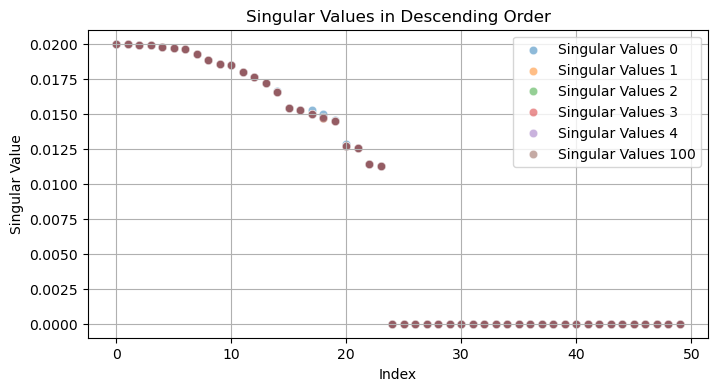

In [187]:
import seaborn as sns

print(singular_values.shape)

num_vals = 50

plt.figure(figsize=(8, 4))
for i in [0, 1, 2, 3, 4, 100]:
    sns.scatterplot(x=np.arange(num_vals), y=singular_values[i,:num_vals], label=f"Singular Values {i}", alpha=0.5)

plt.title("Singular Values in Descending Order")
plt.xlabel("Index")
#plt.yscale("log")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

/var/folders/89/fjbhcnqs1mj37h88z0mvdkc40000gn/T/ipykernel_76733/2004006251.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


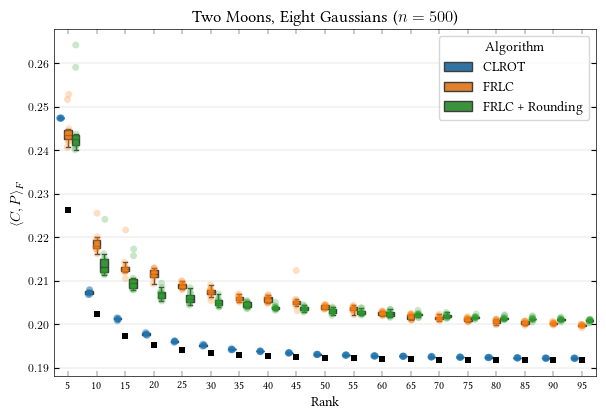

In [308]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("~/plotting/paper.mplstyle")

df = pd.read_csv("../merged_results.csv")
algo_rename_map = {
    "clrot": "CLROT",
    "frlc": "FRLC",
    "frlcround": "FRLC + Rounding"
}
df['algorithm'] = df['algorithm'].replace(algo_rename_map)
lower_bounds = df[~df['lower_bound'].isna()][['rank', 'lower_bound', 'algorithm']].drop_duplicates()

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.stripplot(
    data=df[(df['rank'] > 1) & (df['rank'] < 100)],
    x='rank',
    y='objective_cost',
    hue='algorithm',
    dodge=True,
    alpha=0.25,
    ax=ax,
    legend=False,
)
sns.boxplot(
    data=df[(df['rank'] > 1) & (df['rank'] < 100)],
    x='rank',
    y='objective_cost',
    hue='algorithm',
    showfliers=False,
    ax=ax,
    legend=True
)
# add lower bound using ax.scatter (avoid using hue and linestyle in sns.scatterplot)
lower_bounds_filtered = lower_bounds[(lower_bounds['rank'] > 1) & (lower_bounds['rank'] < 100)]
sns.stripplot(
    data=lower_bounds_filtered,
    x='rank',
    y='lower_bound',
    color='black',
    marker='s',
    label='Lower Bound',
    ax=ax
)


# Remove duplicate legend entries by keeping only the first set
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:len(algo_rename_map)], labels[0:len(algo_rename_map)], title="Algorithm")
ax.set_title("Two Moons, Eight Gaussians ($n = 500$)")
ax.set_xlabel("Rank")
ax.set_ylabel(r"$\langle C, P \rangle_F$")
#fig.legend(title="Algorithm")
fig.show()
fig.savefig("two_moons_eight_gaussians.pdf", bbox_inches='tight')

In [ ]:


X = jnp.array([[0.5, 0.3, 0.7, 0.9, 1.3], [0.5, 0.3, 0.7, 0.9, 1.3]])
t = jnp.array([1.7, 10])
simplex_projection(X, t)

[[1.3 0.9 0.7 0.5 0.3]
 [1.3 0.9 0.7 0.5 0.3]]
[[1.3       2.1999998 2.8999999 3.3999999 3.6999998]
 [1.3       2.1999998 2.8999999 3.3999999 3.6999998]]
[[ 1.7         0.6500001   0.30000004  0.07500005 -0.09999993]
 [10.          4.8         3.0666668   2.15        1.5600002 ]]
[3 4]


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/89/fjbhcnqs1mj37h88z0mvdkc40000gn/T/ipykernel_76733/2757497940.py:2: SyntaxWarning: invalid escape sequence '\s'
  """


Array([ 0.42499995, -1.2600001 ], dtype=float32)

In [29]:
arr = np.array([1, 2, 3])
arr[None,:]

array([[1, 2, 3]])